In [13]:
# =============================================================================
# 2026 flash-test I–V curves at multiple irradiance levels
# =============================================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


# =============================================================================
# Paths
# =============================================================================

PROJECT_ROOT = Path(r"C:/Users/amina/Thesis/Final Pipeline")

FLASH_TEST_DIR = PROJECT_ROOT / "data_raw" / "flash_tests"
INPUT_FILE = FLASH_TEST_DIR / "flash test raw labelled 1000 G.xlsx"

OUTPUT_DIR = PROJECT_ROOT / "results" / "flash_tests"
FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"

for directory in [FIG_DIR, TABLE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Input file exists:", INPUT_FILE.exists())
print("Input file:", INPUT_FILE)


# =============================================================================
# Plot style
# =============================================================================

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 300,

    # Thesis font
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",

    # Font sizes
    "font.size": 12,
    "axes.titlesize": 14,      # subplot/module titles
    "axes.labelsize": 12,      # axis labels
    "xtick.labelsize": 10.5,
    "ytick.labelsize": 10.5,
    "legend.fontsize": 12,

    # Grid
    "axes.grid": True,
    "grid.alpha": 0.25,
})

# Module-category colours used only where needed
TYPE_COLOURS = {
    "Reference": "#009E73",
    "uCrack": "#D55E00",
    "PID/Reference": "#0072B2",
    "Unknown": "#666666",
}

# Irradiance colours for IV curves
# Not blue/orange/green. Also distinguishable in black-and-white by marker/line style.
IRRAD_STYLE = {
    600:  {"color": "#4D4D4D", "marker": "^", "linestyle": "-."},  # dark grey
    800:  {"color": "#C51B7D", "marker": "s", "linestyle": "--"},  # magenta
    1000: {"color": "#6A3D9A", "marker": "o", "linestyle": "-"},   # purple
}

BLACK = "#111111"


# =============================================================================
# Helper functions
# =============================================================================

def save_figure(fig, filename: str) -> None:
    """
    Save figure as PNG and PDF.
    """
    png_path = FIG_DIR / f"{filename}.png"
    pdf_path = FIG_DIR / f"{filename}.pdf"

    fig.savefig(png_path, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")

    print("Saved:")
    print(png_path)
    print(pdf_path)


def normalise_type_label(value):
    """
    Normalise module category labels.
    """
    if pd.isna(value):
        return "Unknown"

    value_str = str(value).strip()

    if value_str in TYPE_COLOURS:
        return value_str

    value_low = value_str.lower()

    if "pid" in value_low:
        return "PID/Reference"
    if "ucrack" in value_low or "microcrack" in value_low or "crack" in value_low:
        return "uCrack"
    if "ref" in value_low:
        return "Reference"

    return "Unknown"


# =============================================================================
# Load labelled IV point data
# =============================================================================

iv_2026 = pd.read_excel(INPUT_FILE).copy()

# Remove accidental spaces in column names, e.g. "Irradiance "
iv_2026.columns = [col.strip() for col in iv_2026.columns]

required_columns = ["Module_ID", "Type", "Voltage", "Current", "Irradiance", "Year"]
missing_columns = [col for col in required_columns if col not in iv_2026.columns]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

# Convert numeric fields
iv_2026["Module_ID"] = pd.to_numeric(iv_2026["Module_ID"], errors="coerce")
iv_2026["Voltage"] = pd.to_numeric(iv_2026["Voltage"], errors="coerce")
iv_2026["Current"] = pd.to_numeric(iv_2026["Current"], errors="coerce")
iv_2026["Irradiance"] = pd.to_numeric(iv_2026["Irradiance"], errors="coerce")
iv_2026["Year"] = pd.to_numeric(iv_2026["Year"], errors="coerce")

# Normalise module type labels
iv_2026["Type"] = iv_2026["Type"].apply(normalise_type_label)

# Drop unusable rows
iv_2026 = (
    iv_2026
    .dropna(subset=["Module_ID", "Voltage", "Current", "Irradiance", "Year", "Type"])
    .copy()
)

iv_2026["Module_ID"] = iv_2026["Module_ID"].astype(int)
iv_2026["Irradiance"] = iv_2026["Irradiance"].astype(int)
iv_2026["Year"] = iv_2026["Year"].astype(int)

# Keep 2026 data only
iv_2026 = iv_2026.loc[iv_2026["Year"] == 2026].copy()

# Calculate power at each measured IV point
iv_2026["Power"] = iv_2026["Voltage"] * iv_2026["Current"]

iv_2026 = (
    iv_2026
    .sort_values(["Module_ID", "Irradiance", "Voltage"])
    .reset_index(drop=True)
)

module_ids = sorted(iv_2026["Module_ID"].unique())
irradiance_levels = sorted(iv_2026["Irradiance"].unique())

print("Loaded IV data shape:", iv_2026.shape)
print("Modules:", module_ids)
print("Irradiance levels:", irradiance_levels)

display(iv_2026.head())


# =============================================================================
# IV data summary table
# =============================================================================

iv_2026_summary = (
    iv_2026
    .groupby(["Module_ID", "Type", "Irradiance"], as_index=False)
    .agg(
        n_points=("Voltage", "size"),
        voltage_min=("Voltage", "min"),
        voltage_max=("Voltage", "max"),
        current_min=("Current", "min"),
        current_max=("Current", "max"),
        measured_pmax=("Power", "max"),
    )
    .sort_values(["Module_ID", "Irradiance"])
    .reset_index(drop=True)
)

display(iv_2026_summary)

iv_2026_summary.to_csv(
    TABLE_DIR / "iv_2026_multi_irradiance_curve_summary.csv",
    index=False,
)


# =============================================================================
# Save MPP table
# =============================================================================

mpp_table = (
    pd.DataFrame(mpp_rows)
    .sort_values(["Module_ID", "Irradiance_W_m2"])
    .reset_index(drop=True)
)

display(mpp_table)

mpp_table.to_csv(
    TABLE_DIR / "iv_2026_multi_irradiance_mpp_summary.csv",
    index=False,
)


Input file exists: True
Input file: C:\Users\amina\Thesis\Final Pipeline\data_raw\flash_tests\flash test raw labelled 1000 G.xlsx
Loaded IV data shape: (7786, 7)
Modules: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
Irradiance levels: [np.int64(600), np.int64(800), np.int64(1000)]


,Module_ID,Type,Voltage,Current,Irradiance,Year,Power
0,1,PID/Reference,0.533,5.1745,600,2026,2.758009
1,1,PID/Reference,0.788,5.1751,600,2026,4.077979
2,1,PID/Reference,1.043,5.1747,600,2026,5.397212
3,1,PID/Reference,1.327,5.1737,600,2026,6.865500
4,1,PID/Reference,1.528,5.1751,600,2026,7.907553


,Module_ID,Type,Irradiance,n_points,voltage_min,voltage_max,current_min,current_max,measured_pmax
0,1,PID/Reference,600,293,0.533,21.841,0.0146,5.175100,86.456568
1,1,PID/Reference,800,231,0.494,22.111,0.0380,6.845000,113.872492
2,1,PID/Reference,1000,240,0.653,22.543,0.0380,8.633000,144.724059
3,2,Reference,600,228,0.585,22.044,0.0143,5.176100,87.890862
4,2,Reference,800,220,0.619,22.331,0.0380,6.870000,116.209304
5,2,Reference,1000,234,0.689,22.566,0.0840,8.635000,145.463712
6,3,uCrack,600,247,0.608,21.503,0.0134,4.837400,62.434242
7,3,uCrack,800,245,0.651,21.822,0.0720,6.308000,80.439323
8,3,uCrack,1000,240,0.662,22.094,0.0790,7.762000,98.049001
9,4,uCrack,600,363,0.622,21.973,0.0142,5.231400,84.589503


,Module_ID,Type,Irradiance_W_m2,P_mpp_W,V_mpp_V,I_mpp_A
0,1,PID/Reference,600,86.456568,17.772,4.864763
1,1,PID/Reference,800,113.872492,17.803,6.396253
2,1,PID/Reference,1000,144.724059,17.894,8.087854
3,2,Reference,600,87.890862,17.935,4.900522
4,2,Reference,800,116.209304,17.924,6.483447
5,2,Reference,1000,145.463712,17.927,8.114225
6,3,uCrack,600,62.434242,16.522,3.778855
7,3,uCrack,800,80.439323,16.497,4.875997
8,3,uCrack,1000,98.049001,16.530,5.931579
9,4,uCrack,600,84.589503,17.810,4.749551


Saved:
C:\Users\amina\Thesis\Final Pipeline\results\flash_tests\figures\iv_2026_multi_irradiance_multipanel_all_modules_compact.png
C:\Users\amina\Thesis\Final Pipeline\results\flash_tests\figures\iv_2026_multi_irradiance_multipanel_all_modules_compact.pdf


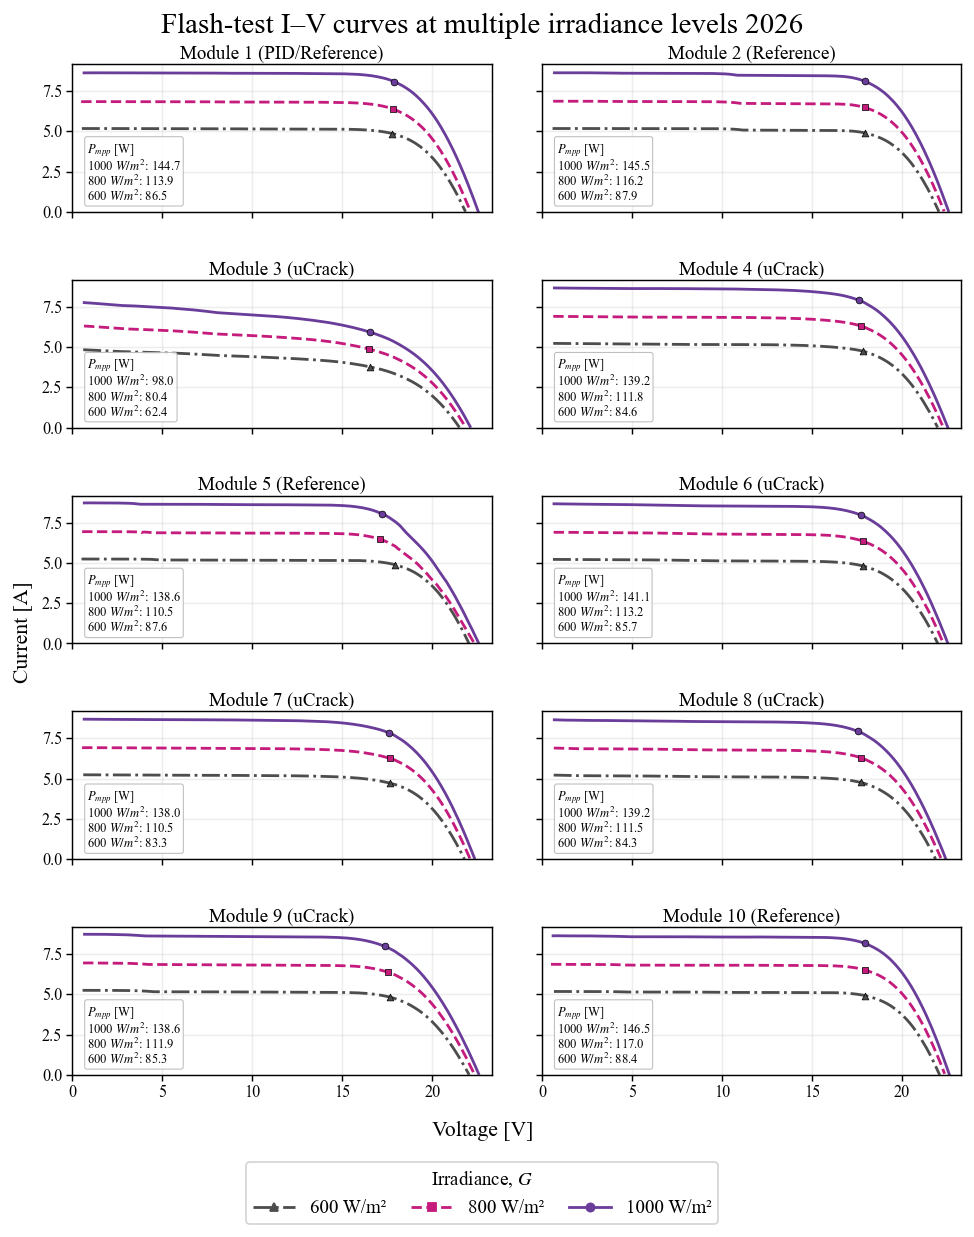

,Module_ID,Type,Irradiance_W_m2,P_mpp_W,V_mpp_V,I_mpp_A
0,1,PID/Reference,600,86.456568,17.772,4.864763
1,1,PID/Reference,800,113.872492,17.803,6.396253
2,1,PID/Reference,1000,144.724059,17.894,8.087854
3,2,Reference,600,87.890862,17.935,4.900522
4,2,Reference,800,116.209304,17.924,6.483447
5,2,Reference,1000,145.463712,17.927,8.114225
6,3,uCrack,600,62.434242,16.522,3.778855
7,3,uCrack,800,80.439323,16.497,4.875997
8,3,uCrack,1000,98.049001,16.530,5.931579
9,4,uCrack,600,84.589503,17.810,4.749551


In [14]:

# =============================================================================
# Multipanel IV curves at multiple irradiance levels — compact A4 version
# =============================================================================

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 300,

    # Thesis font
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",

    # Font sizes
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 10.5,

    # Grid
    "axes.grid": True,
    "grid.alpha": 0.22,
})

IRRAD_STYLE = {
    600:  {"color": "#4D4D4D", "marker": "^", "linestyle": "-."},  # dark grey
    800:  {"color": "#C51B7D", "marker": "s", "linestyle": "--"},  # magenta
    1000: {"color": "#6A3D9A", "marker": "o", "linestyle": "-"},   # purple
}

plot_irradiance_levels = [G for G in [600, 800, 1000] if G in irradiance_levels]

n_modules = len(module_ids)
ncols = 2
nrows = int(np.ceil(n_modules / ncols))

# More compact A4-friendly size
fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(7.6, 9.6),
    sharex=True,
    sharey=True,
)

axes = np.atleast_1d(axes).flatten()

x_max = iv_2026["Voltage"].max() * 1.03
y_max = iv_2026["Current"].max() * 1.05

mpp_rows = []

for ax, module_id in zip(axes, module_ids):
    module_df = (
        iv_2026
        .loc[iv_2026["Module_ID"] == module_id]
        .copy()
        .sort_values(["Irradiance", "Voltage"])
    )

    module_type = module_df["Type"].iloc[0]
    ax.set_title(f"Module {module_id} ({module_type})", fontsize=10.5, pad=3)

    mpp_summary = {}

    for G in plot_irradiance_levels:
        sub = (
            module_df
            .loc[module_df["Irradiance"] == G]
            .copy()
            .sort_values("Voltage")
        )

        if sub.empty:
            continue

        style = IRRAD_STYLE[G]

        ax.plot(
            sub["Voltage"],
            sub["Current"],
            color=style["color"],
            linestyle=style["linestyle"],
            linewidth=1.55,
        )

        mpp_idx = sub["Power"].idxmax()
        mpp_row = sub.loc[mpp_idx]

        ax.scatter(
            mpp_row["Voltage"],
            mpp_row["Current"],
            s=14,
            color=style["color"],
            marker=style["marker"],
            edgecolor="black",
            linewidth=0.4,
            zorder=4,
        )

        mpp_summary[G] = mpp_row

        mpp_rows.append({
            "Module_ID": module_id,
            "Type": module_type,
            "Irradiance_W_m2": G,
            "P_mpp_W": mpp_row["Power"],
            "V_mpp_V": mpp_row["Voltage"],
            "I_mpp_A": mpp_row["Current"],
        })

    # Compact Pmpp box
    pmpp_lines = [r"$P_{mpp}$ [W]"]
    for G in [1000, 800, 600]:
        if G in mpp_summary:
            row = mpp_summary[G]
            pmpp_lines.append(f"{G} $W/m^{2}$: {row['Power']:.1f}")

    ax.text(
        0.035,
        0.055,
        "\n".join(pmpp_lines),
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=7.0,
        linespacing=1.0,
        bbox=dict(
            boxstyle="round,pad=0.18",
            facecolor="white",
            edgecolor="#B8B8B8",
            linewidth=0.6,
            alpha=0.90,
        ),
    )

    ax.set_xlim(0, x_max)
    ax.set_ylim(0, y_max)

    ax.tick_params(axis="both", which="major", pad=2)

# Hide unused axes
for ax in axes[n_modules:]:
    ax.set_visible(False)

# Figure-level title and labels
fig.suptitle(
    "Flash-test I–V curves at multiple irradiance levels 2026",
    fontsize=16,
    y=0.996,
)

fig.supxlabel("Voltage [V]", fontsize=12, y=0.092)
fig.supylabel("Current [A]", fontsize=12, x=0.025)

legend_handles = [
    Line2D(
        [0], [0],
        color=IRRAD_STYLE[G]["color"],
        linestyle=IRRAD_STYLE[G]["linestyle"],
        marker=IRRAD_STYLE[G]["marker"],
        markersize=4.5,
        linewidth=1.55,
        label=f"{G} W/m²",
    )
    for G in plot_irradiance_levels
]

fig.legend(
    handles=legend_handles,
    title="Irradiance, $G$",
    title_fontsize=10.5,
    fontsize=10.5,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.018),
    ncol=len(plot_irradiance_levels),
    frameon=True,
    borderpad=0.35,
    handlelength=2.2,
    columnspacing=1.3,
)

# Compact layout: less title gap, less bottom whitespace
fig.subplots_adjust(
    left=0.085,
    right=0.985,
    top=0.955,
    bottom=0.145,
    hspace=0.46,
    wspace=0.12,
)

save_figure(fig, "iv_2026_multi_irradiance_multipanel_all_modules_compact")
plt.show()

# Save MPP table
mpp_table = (
    pd.DataFrame(mpp_rows)
    .sort_values(["Module_ID", "Irradiance_W_m2"])
    .reset_index(drop=True)
)

display(mpp_table)

mpp_table.to_csv(
    TABLE_DIR / "iv_2026_multi_irradiance_mpp_summary.csv",
    index=False,
)
